# Human-Value Inference on ParlaMint Arguments

This notebook uses the `InferenceEngine` module to:
1. Load the ParlaMint arguments dataset (JSONL)
2. Load the fine-tuned RoBERTa classifier
3. Predict Schwartz human values for each argument
4. Aggregate per-politician and render **triple radar charts** (specific / basic / higher-order) into `reports/`

All heavy lifting lives in [`src/inference_engine.py`](src/inference_engine.py).

In [1]:
import sys
sys.path.append('.')

from src.inference_engine import InferenceEngine

DATASET = 'parlamint_arguments_dataset_TOY.jsonl'  # swap for _ALL_YEARS.jsonl in production

engine = InferenceEngine(
    model_name='roberta-base',
    weights_path='models/saved_weights/roberta_best.pt',
    reports_dir='reports',
    threshold=0.49,
)

## Run the full pipeline

One call: loads data → loads model → predicts → saves one radar chart per speaker.

In [2]:
results_df, chart_paths = engine.run(DATASET, batch_size=32)
results_df.head(10)

✅ Loaded 52 arguments from parlamint_arguments_dataset_TOY.jsonl


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Loaded fine-tuned weights from models/saved_weights/roberta_best.pt on cuda


Inference:   0%|          | 0/2 [00:00<?, ?it/s]

...

Inference: 100%|██████████| 2/2 [00:29<00:00, 12.01s/it]

Inference: 100%|██████████| 2/2 [00:29<00:00, 14.55s/it]

💾 Saved reports/sánchez_pérez_castejón_pedro_radar.png


💾 Saved reports/abascal_conde_santiago_radar.png

🎉 Generated 2 radar chart(s) in reports/


,Speaker,Party,Values
0,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Achievement, Power: dominance, Power: resourc..."
1,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Achievement, Power: resources, Universalism: ..."
2,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Achievement, Power: resources, Universalism: ..."
3,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Conformity: rules, Benevolence: caring, Unive..."
4,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Self-direction: action, Power: dominance, Uni..."
5,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Achievement, Power: dominance, Security: soci..."
6,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Achievement, Power: dominance, Security: soci..."
7,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Power: resources, Security: personal, Univers..."
8,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Power: resources, Security: personal, Univers..."
9,"Sánchez Pérez-Castejón, Pedro",PSOE,"[Universalism: concern, Universalism: toleranc..."


## Inspect a single politician

Render the triple radar inline for any speaker present in the dataset.

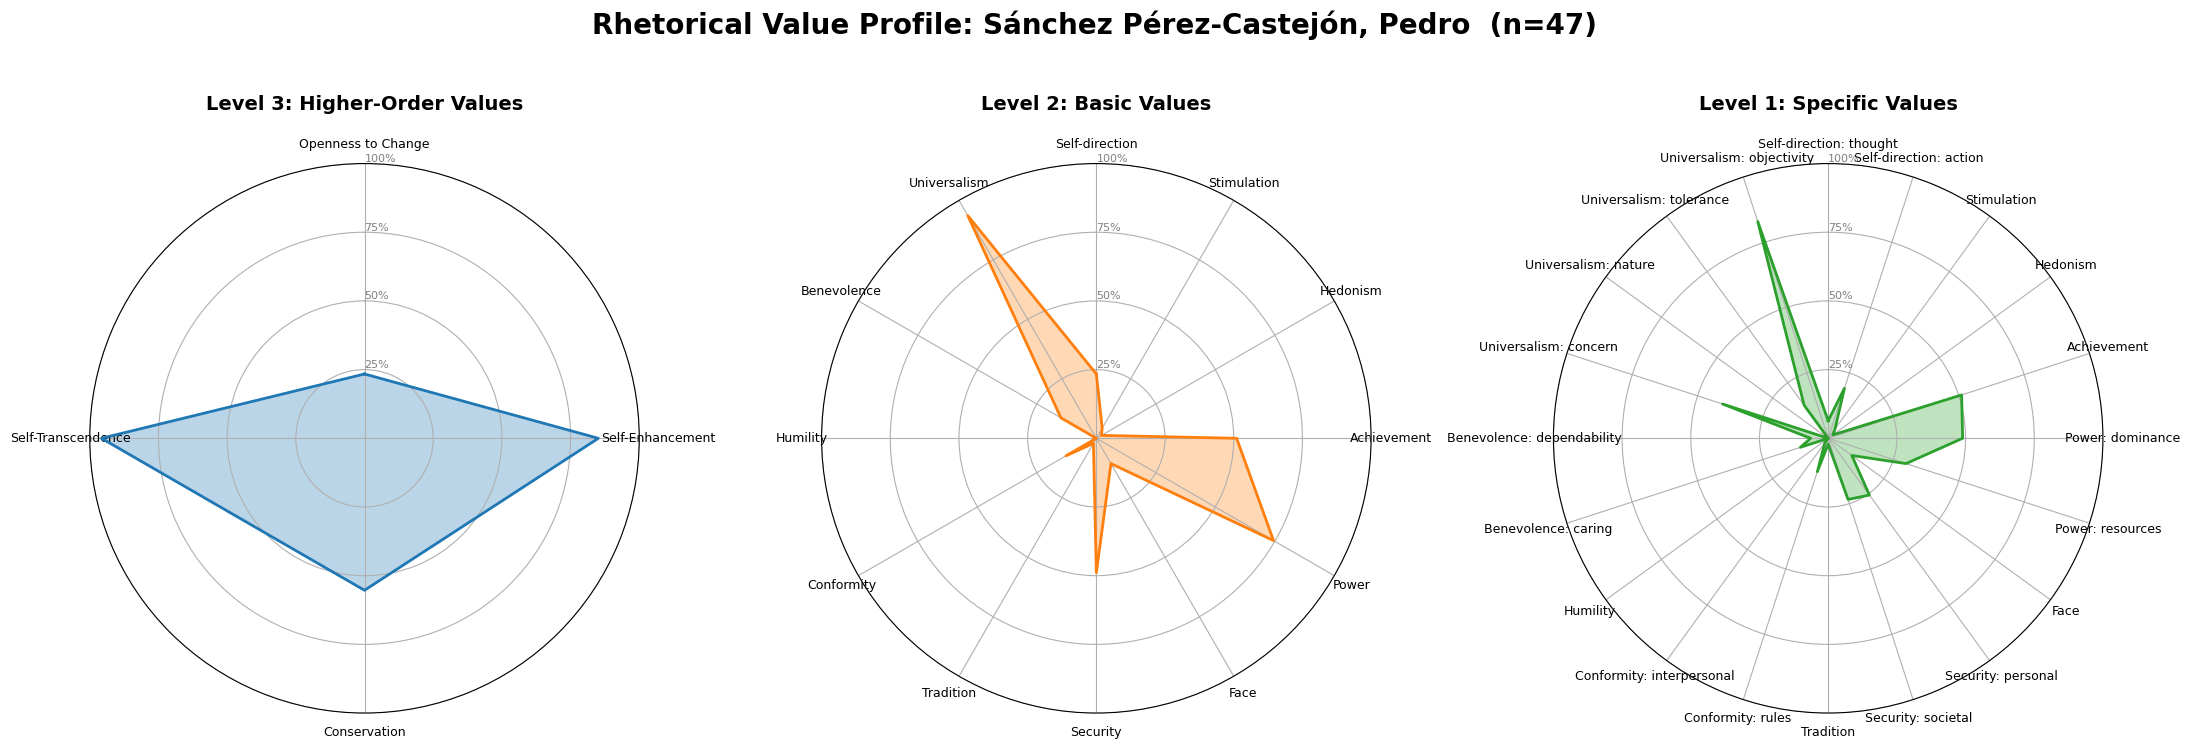

In [3]:
%matplotlib inline
engine.plot_speaker('Sánchez Pérez-Castejón, Pedro', save=False, show=True)

## Raw aggregated frequencies

Access the numeric value-frequency breakdown (percentage of arguments expressing each value).

In [4]:
import pandas as pd

agg = engine.aggregate('Sánchez Pérez-Castejón, Pedro')
print(f"Based on {agg['n_arguments']} arguments\n")

pd.DataFrame({
    'Higher-Order (%)': pd.Series(agg['higher']),
    'Basic (%)': pd.Series(agg['basic']),
    'Specific (%)': pd.Series(agg['specific']),
}).round(1)

Based on 47 arguments



,Higher-Order (%),Basic (%),Specific (%)
Achievement,NaN,51.1,51.1
Benevolence,NaN,14.9,NaN
Benevolence: caring,NaN,NaN,10.6
Benevolence: dependability,NaN,NaN,6.4
Conformity,NaN,12.8,NaN
Conformity: interpersonal,NaN,NaN,2.1
Conformity: rules,NaN,NaN,12.8
Conservation,55.3,NaN,NaN
Face,NaN,10.6,10.6
Hedonism,NaN,2.1,2.1
